# Part 2

In [122]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
from scipy.io import loadmat
from scipy.ndimage import convolve1d
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
import seaborn as sns
sns.set()
import re



plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120

### Load the data

Import and list all files

In [8]:
# Path to folder containing the 27 MAT files
DATA_DIR = "./data"   # change if needed, e.g. "/data" on the VM

# Find all .mat files in the folder
mat_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".mat")]
)

print(f"Found {len(mat_files)} .mat files in {DATA_DIR}:")
for f in mat_files:
    print("  ", f)


Found 27 .mat files in ./data:
   S10_A1_E1.mat
   S11_A1_E1.mat
   S12_A1_E1.mat
   S13_A1_E1.mat
   S14_A1_E1.mat
   S15_A1_E1.mat
   S16_A1_E1.mat
   S17_A1_E1.mat
   S18_A1_E1.mat
   S19_A1_E1.mat
   S1_A1_E1.mat
   S20_A1_E1.mat
   S21_A1_E1.mat
   S22_A1_E1.mat
   S23_A1_E1.mat
   S24_A1_E1.mat
   S25_A1_E1.mat
   S26_A1_E1.mat
   S27_A1_E1.mat
   S2_A1_E1.mat
   S3_A1_E1.mat
   S4_A1_E1.mat
   S5_A1_E1.mat
   S6_A1_E1.mat
   S7_A1_E1.mat
   S8_A1_E1.mat
   S9_A1_E1.mat


Store in one datastructure but keep easily separable for followings tasks

`subjects` is a list where each entry is a dictionary with the following keys:

- **subject_id** → integer like `1, 2, 3, ...`
- **filename** → original `.mat` filename
- **emg** → array of shape `(n_samples, 10)` containing the EMG data
- **stimulus** → array of shape `(n_samples,)` with integer labels  
  (`0 = rest`, `1–12 = movement classes`)
- **repetition** → array of shape `(n_samples,)` with repetition indices  
  (`0 = none`, `1–10 = actual repetition`)

In [42]:
subjects = []

for fname in mat_files:
    path = os.path.join(DATA_DIR, fname)
    data = loadmat(path)
    
    # Extract variables in the same way as Exercise 11
    emg = data["emg"]                    # shape (T, 10)
    stimulus = data["restimulus"]        # shape (T, 1) or (T,)
    repetition = data["rerepetition"]    # shape (T, 1) or (T,)

    # squeeze to 1D vectors for convenience
    stimulus = np.squeeze(stimulus).astype(int)
    repetition = np.squeeze(repetition).astype(int)
    
    # Parse subject ID from filename, e.g. "S12_A1_E1.mat" -> 12
    m = re.search(r"S(\d+)_A1_E1\.mat", fname, re.IGNORECASE)
    if m:
        subject_id = int(m.group(1))
    else:
        subject_id = len(subjects) + 1

    subjects.append(
        {
            "subject_id": subject_id,
            "filename": fname,
            "emg": emg,
            "stimulus": stimulus,
            "repetition": repetition,
        }
    )

# 🔹 NEW: sort subjects by true subject_id (1..27)
subjects = sorted(subjects, key=lambda s: s["subject_id"])

print(f"Loaded {len(subjects)} subjects.")

# Quick sanity print
for subj in subjects:
    emg = subj["emg"]
    print(
        f"Subject {subj['subject_id']:2d} ({subj['filename']}): "
        f"EMG shape = {emg.shape}, "
        f"unique stimuli = {np.unique(subj['stimulus']).size - 1}, "
        f"unique reps = {np.unique(subj['repetition']).size - 1}"
    )

print(f"Loaded {len(subjects)} subjects.")

# Quick sanity print
for subj in subjects:
    emg = subj["emg"]
    print(
        f"Subject {subj['subject_id']:2d} ({subj['filename']}): "
        f"EMG shape = {emg.shape}, "
        f"unique stimuli = {np.unique(subj['stimulus']).size - 1}, "
        f"unique reps = {np.unique(subj['repetition']).size - 1}"
    )


Loaded 27 subjects.
Subject  1 (S1_A1_E1.mat): EMG shape = (101014, 10), unique stimuli = 12, unique reps = 10
Subject  2 (S2_A1_E1.mat): EMG shape = (100686, 10), unique stimuli = 12, unique reps = 10
Subject  3 (S3_A1_E1.mat): EMG shape = (100720, 10), unique stimuli = 12, unique reps = 10
Subject  4 (S4_A1_E1.mat): EMG shape = (100835, 10), unique stimuli = 12, unique reps = 10
Subject  5 (S5_A1_E1.mat): EMG shape = (100894, 10), unique stimuli = 12, unique reps = 10
Subject  6 (S6_A1_E1.mat): EMG shape = (101083, 10), unique stimuli = 12, unique reps = 10
Subject  7 (S7_A1_E1.mat): EMG shape = (100817, 10), unique stimuli = 12, unique reps = 10
Subject  8 (S8_A1_E1.mat): EMG shape = (100854, 10), unique stimuli = 12, unique reps = 10
Subject  9 (S9_A1_E1.mat): EMG shape = (100925, 10), unique stimuli = 12, unique reps = 10
Subject 10 (S10_A1_E1.mat): EMG shape = (100778, 10), unique stimuli = 12, unique reps = 10
Subject 11 (S11_A1_E1.mat): EMG shape = (100899, 10), unique stimuli 

## 1. Consider now 27 subjects (only exercise set 1 as in part 1). Perform the same preprocessing pipeline as in part 1.  

In [43]:
# Same envelope parameters as in Exercises / Part 1
mov_mean_length  = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

def plot_trial_emg_and_envelope(subject_id, stimulus_id, repetition_id):
    """
    Visualize one trial (all channels) for a given subject.
    All arguments are 1-based labels, matching Ninapro:

    - subject_id: 1..27
    - stimulus_id: 1..12   (0 = rest is ignored)
    - repetition_id: 1..10 (0 = none)
    """

    # --- pick subject by true subject_id (1..27) ---
    matches = [s for s in subjects if s["subject_id"] == subject_id]
    if not matches:
        print(f"No subject with ID {subject_id} found.")
        return
    subj = matches[0]

    emg = subj["emg"]
    stimulus = subj["stimulus"]
    repetition = subj["repetition"]

    # basic sanity checks on labels
    if stimulus_id not in np.unique(stimulus):
        print(f"Stimulus ID {stimulus_id} not found for subject {subject_id}.")
        return
    if repetition_id not in np.unique(repetition):
        print(f"Repetition ID {repetition_id} not found for subject {subject_id}.")
        return

    # select the trial using 1-based labels directly
    idx = (stimulus == stimulus_id) & (repetition == repetition_id)
    if not np.any(idx):
        print(
            f"No samples for subject {subject_id}, "
            f"stimulus {stimulus_id}, repetition {repetition_id}."
        )
        return

    trial = emg[idx, :]              # (T_trial, n_channels)
    env   = convolve1d(trial, mov_mean_weights, axis=0)

    n_channels = trial.shape[1]

    fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True, sharex=True)
    ax = ax.ravel()

    for ch in range(n_channels):
        ax[ch].plot(trial[:, ch], color="lightgray",
                    label="EMG" if ch == 0 else None)
        ax[ch].plot(env[:, ch], color="black",
                    label="Envelope" if ch == 0 else None)
        ax[ch].set_title(f"Channel {ch+1}")   # 1-based channel label

    # hide unused subplots if needed
    for k in range(n_channels, len(ax)):
        ax[k].axis("off")

    if n_channels > 0:
        ax[0].legend()

    plt.suptitle(
        f"Subject {subject_id}, stimulus {stimulus_id}, repetition {repetition_id}\n"
        "EMG (gray) and envelope (black)",
        y=1.02
    )

    plt.show()


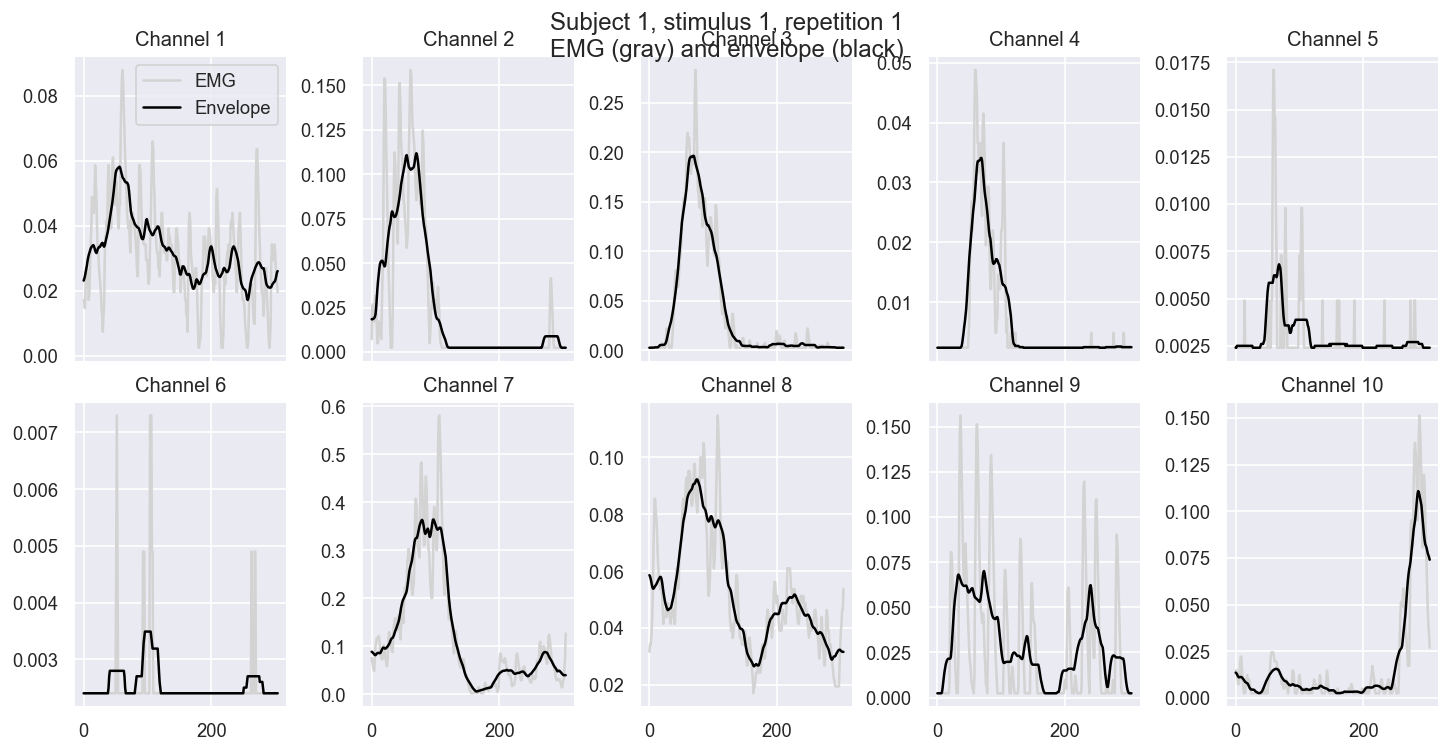

In [47]:
# Subject 1, stimulus 1, repetition 1 (all 1-based labels)
plot_trial_emg_and_envelope(subject_id=1, stimulus_id=1, repetition_id=1)


Automatic flagging (similar to part 1)

In [56]:
def find_bad_trials(
    signal, 
    restimulus, 
    rerepetition, 
    actions, 
    reps, 
    rms_drop_fraction=0.1, 
    min_std=1e-7
):
    """
    Flag (action, repetition) trials where one or more channels are basically 'dead'.
    SAME AS PART 1, except:
        - bad_channels in output are now 1-based instead of 0-based.
    """

    bad_trials = []

    # Global RMS per channel over the full recording
    global_rms = np.sqrt(np.mean(signal**2, axis=0))

    for a in actions:
        for r in reps:
            idx = (restimulus == a) & (rerepetition == r)
            trial = signal[idx, :]
            if trial.size == 0:
                continue

            # Trial-level RMS and std per channel
            trial_rms = np.sqrt(np.mean(trial**2, axis=0))
            trial_std = trial.std(axis=0)

            # Conditions for 'bad' channels
            low_amp = trial_rms < (rms_drop_fraction * global_rms)
            flat    = trial_std < min_std

            # still compute channels 0-based
            bad_ch = np.where(low_amp | flat)[0]

            if len(bad_ch) > 0:

                # 🔹 convert from 0-based → 1-based for OUTPUT ONLY
                bad_ch_1based = (bad_ch + 1).tolist()

                bad_trials.append({
                    "action": int(a),          # already 1-based
                    "repetition": int(r),      # already 1-based
                    "bad_channels": bad_ch_1based,
                    "trial_length": int(trial.shape[0])
                })

    return bad_trials


In [74]:
subject_id = 3  # true subject number, 1..27

# find subject dict by ID
subj = next(s for s in subjects if s["subject_id"] == subject_id)

emg_subj   = subj["emg"]
stim_subj  = subj["stimulus"]
reps_subj  = subj["repetition"]

# unique non-rest actions and non-zero reps for THIS subject only
actions_subj = np.unique(stim_subj)
actions_subj = actions_subj[actions_subj > 0]

unique_reps_subj = np.unique(reps_subj)
unique_reps_subj = unique_reps_subj[unique_reps_subj > 0]

bad_trials_subj = find_bad_trials(
    signal=emg_subj,
    restimulus=stim_subj,
    rerepetition=reps_subj,
    actions=actions_subj,
    reps=unique_reps_subj,
    rms_drop_fraction=0.005,   # same as Part 1 call
    min_std=1e-7
)

print(f"Subject {subject_id} – suspicious trials: {len(bad_trials_subj)}")
bad_trials_subj[:10]



Subject 3 – suspicious trials: 3


[{'action': 2, 'repetition': 7, 'bad_channels': [6], 'trial_length': 266},
 {'action': 2, 'repetition': 10, 'bad_channels': [6], 'trial_length': 355},
 {'action': 3, 'repetition': 10, 'bad_channels': [2], 'trial_length': 531}]

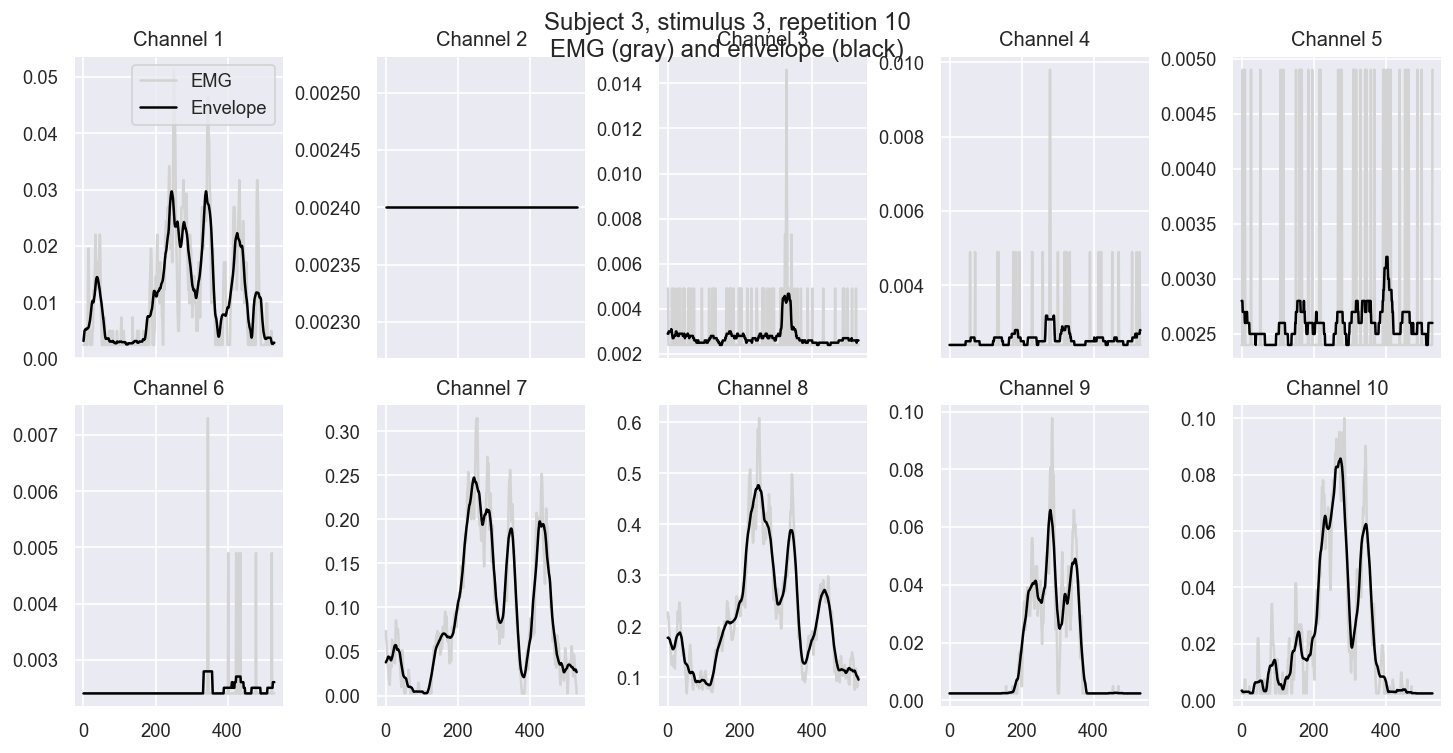

In [76]:
plot_trial_emg_and_envelope(subject_id=3, stimulus_id=3, repetition_id=10)


Loop over subjects

In [66]:
all_bad_trials = {}   # subject_id → list of bad trials

for subj in subjects:   # subjects is already sorted by subject_id
    sid = subj["subject_id"]

    emg_subj = subj["emg"]
    stim_subj = subj["stimulus"]
    reps_subj = subj["repetition"]

    # Unique non-rest actions and non-zero reps for THIS subject
    actions_subj = np.unique(stim_subj)
    actions_subj = actions_subj[actions_subj > 0]

    reps_unique_subj = np.unique(reps_subj)
    reps_unique_subj = reps_unique_subj[reps_unique_subj > 0]

    # Run Part-1 logic
    bad_trials = find_bad_trials(
        signal=emg_subj,
        restimulus=stim_subj,
        rerepetition=reps_subj,
        actions=actions_subj,
        reps=reps_unique_subj,
        rms_drop_fraction=0.005,  # same as your Part 1 setting
        min_std=1e-7
    )

    all_bad_trials[sid] = bad_trials

    # Nice formatted printout
    if len(bad_trials) == 0:
        print(f"Subject {sid:2d}: OK (no suspicious trials)")
    else:
        bad_ch_all = sorted({ch for trial in bad_trials for ch in trial['bad_channels']})
        print(
            f"Subject {sid:2d}: {len(bad_trials):2d} suspicious trials – "
            f"bad channels (1-based): {bad_ch_all}"
        )


Subject  1: 12 suspicious trials – bad channels (1-based): [2, 4, 6]
Subject  2: OK (no suspicious trials)
Subject  3:  3 suspicious trials – bad channels (1-based): [2, 6]
Subject  4: OK (no suspicious trials)
Subject  5: OK (no suspicious trials)
Subject  6: OK (no suspicious trials)
Subject  7:  2 suspicious trials – bad channels (1-based): [2]
Subject  8: OK (no suspicious trials)
Subject  9:  7 suspicious trials – bad channels (1-based): [2, 4, 6]
Subject 10: OK (no suspicious trials)
Subject 11:  1 suspicious trials – bad channels (1-based): [9]
Subject 12:  9 suspicious trials – bad channels (1-based): [6]
Subject 13:  4 suspicious trials – bad channels (1-based): [2, 4]
Subject 14: OK (no suspicious trials)
Subject 15: OK (no suspicious trials)
Subject 16:  1 suspicious trials – bad channels (1-based): [4, 6]
Subject 17: OK (no suspicious trials)
Subject 18:  5 suspicious trials – bad channels (1-based): [4, 6, 9]
Subject 19: 32 suspicious trials – bad channels (1-based): [4, 5

In [68]:
print("\n=== Full Detailed Output for All Subjects ===\n")

for subj in subjects:
    sid = subj["subject_id"]

    emg_subj  = subj["emg"]
    stim_subj = subj["stimulus"]
    reps_subj = subj["repetition"]

    # Extract valid movements and repetitions
    actions_subj = np.unique(stim_subj)
    actions_subj = actions_subj[actions_subj > 0]

    reps_unique_subj = np.unique(reps_subj)
    reps_unique_subj = reps_unique_subj[reps_unique_subj > 0]

    # Run your updated Part-1 logic
    bad_trials_subj = find_bad_trials(
        signal=emg_subj,
        restimulus=stim_subj,
        rerepetition=reps_subj,
        actions=actions_subj,
        reps=reps_unique_subj,
        rms_drop_fraction=0.005,
        min_std=1e-7
    )

    print(f"\n--- Subject {sid} ---")
    print(f"Found {len(bad_trials_subj)} suspicious trials")

    if len(bad_trials_subj) == 0:
        continue

    # Print the full list of trials, exactly like individual call
    for entry in bad_trials_subj:
        print(entry)



=== Full Detailed Output for All Subjects ===


--- Subject 1 ---
Found 12 suspicious trials
{'action': 2, 'repetition': 3, 'bad_channels': [4], 'trial_length': 233}
{'action': 2, 'repetition': 4, 'bad_channels': [6], 'trial_length': 234}
{'action': 2, 'repetition': 9, 'bad_channels': [6], 'trial_length': 229}
{'action': 11, 'repetition': 2, 'bad_channels': [6], 'trial_length': 285}
{'action': 11, 'repetition': 6, 'bad_channels': [6], 'trial_length': 240}
{'action': 11, 'repetition': 9, 'bad_channels': [6], 'trial_length': 238}
{'action': 12, 'repetition': 4, 'bad_channels': [6], 'trial_length': 239}
{'action': 12, 'repetition': 5, 'bad_channels': [2], 'trial_length': 526}
{'action': 12, 'repetition': 6, 'bad_channels': [4], 'trial_length': 261}
{'action': 12, 'repetition': 7, 'bad_channels': [4], 'trial_length': 185}
{'action': 12, 'repetition': 8, 'bad_channels': [4, 6], 'trial_length': 521}
{'action': 12, 'repetition': 9, 'bad_channels': [4], 'trial_length': 224}

--- Subject 2 ---

Removing 5/10 channels is probably a bad idea

In [79]:
# TODO maybe remove

Check for negative values

In [78]:
print("=== Checking for negative EMG values across all subjects ===\n")

negative_entries = []  # store structured results if needed later

for subj in subjects:
    sid = subj["subject_id"]
    emg = subj["emg"]
    stimulus = subj["stimulus"]
    repetition = subj["repetition"]

    actions = np.unique(stimulus)
    actions = actions[actions > 0]  # exclude rest

    reps = np.unique(repetition)
    reps = reps[reps > 0]  # exclude 0

    for a in actions:
        for r in reps:
            idx = (stimulus == a) & (repetition == r)
            trial = emg[idx, :]
            if trial.size == 0:
                continue

            # channel-wise negative detection
            neg_mask = np.any(trial < 0, axis=0)   # boolean vector, per channel
            if np.any(neg_mask):
                bad_channels = (np.where(neg_mask)[0] + 1).tolist()  # 1-based

                entry = {
                    "subject_id": sid,
                    "action": int(a),
                    "repetition": int(r),
                    "channels": bad_channels,
                }
                negative_entries.append(entry)

                print(f"Subject {sid:2d}, action {a}, repetition {r}: "
                      f"negative values in channels {bad_channels}")

if len(negative_entries) == 0:
    print("✓ No negative EMG values detected in any subject.")
else:
    print(f"\nTotal problematic trials: {len(negative_entries)}")


=== Checking for negative EMG values across all subjects ===

✓ No negative EMG values detected in any subject.


In [97]:
# TODO those heatmaps

## 2. Extract the same set of features. Now look at the values of those features across the different subjects. Are there any similarity/discrepancies between the subjects?  

Reuse what we have from part 1

<span style="color:red">TODO: frequency domain features</span>


In [90]:
# === Feature functions (exact same as Part 1) ===

def compute_mav(trial):
    return np.mean(np.abs(trial), axis=0)

def compute_rms(trial):
    return np.sqrt(np.mean(trial**2, axis=0))

def compute_wl(trial):
    return np.sum(np.abs(np.diff(trial, axis=0)), axis=0)

# def compute_zc(trial, threshold=0.01):
#     zc = np.zeros(trial.shape[1], dtype=int)
#     for ch in range(trial.shape[1]):
#         s = trial[:, ch]
#         zc[ch] = np.sum(
#             (s[:-1] * s[1:] < 0) &
#             (np.abs(s[:-1] - s[1:]) >= threshold)
#         )
#     return zc

def compute_ssc(trial, threshold=0.01):
    ssc = np.zeros(trial.shape[1], dtype=int)
    for ch in range(trial.shape[1]):
        s = trial[:, ch]
        ssc[ch] = np.sum(
            ((s[1:-1] - s[:-2]) * (s[2:] - s[1:-1]) < 0) &
            (np.abs(s[1:-1] - s[:-2]) >= threshold) &
            (np.abs(s[2:] - s[1:-1]) >= threshold)
        )
    return ssc

def compute_std(trial):
    return np.std(trial, axis=0)

def compute_maxav(trial):
    return np.max(np.abs(trial), axis=0)


In [91]:
feature_fns = [
    compute_mav,
    compute_rms,
    compute_wl,
    # compute_zc,
    compute_ssc,
    compute_std,
    compute_maxav,
]

feature_names = [
    "MAV",
    "RMS",
    "WL",
    # "ZC",
    "SSC",
    "STD",
    "MAXAV",
]


Feature extraction for each subject

In [92]:
def extract_features_for_subject(subject):
    """
    Extracts the same features as Part 1 for an entire subject.
    Returns:
        X (n_trials × n_features)
        y (n_trials,)
        trial_info (list of dict with subject_id, action, repetition)
    """
    emg = subject["emg"]
    stimulus = subject["stimulus"]
    repetition = subject["repetition"]
    sid = subject["subject_id"]

    actions = np.unique(stimulus)
    actions = actions[actions > 0]

    reps = np.unique(repetition)
    reps = reps[reps > 0]

    X = []
    y = []
    trial_info = []

    for a in actions:
        for r in reps:
            idx = (stimulus == a) & (repetition == r)
            trial = emg[idx, :]
            if trial.size == 0:
                continue

            # Envelope (same as Part 1)
            env = convolve1d(trial, mov_mean_weights, axis=0)

            # Compute all features (same order as Part 1)
            feats = []
            for f in feature_fns:
                feats.append(f(env))  # shape (10,)
            feat_vec = np.concatenate(feats)

            X.append(feat_vec)
            y.append(a)

            trial_info.append({
                "subject_id": sid,
                "action": int(a),
                "repetition": int(r)
            })

    return np.vstack(X), np.array(y), trial_info


In [93]:
subject_feature_stats = {}  # subject_id → {"mean": ..., "std": ...}

for subj in subjects:
    sid = subj["subject_id"]
    X_s, y_s, info_s = extract_features_for_subject(subj)

    subject_feature_stats[sid] = {
        "mean": np.mean(X_s, axis=0),
        "std": np.std(X_s, axis=0),
        "n_trials": X_s.shape[0]
    }

print("Computed feature stats for all subjects.")

Computed feature stats for all subjects.


In [94]:
flat_feature_names = []
for fname in feature_names:     # ["MAV", "RMS", ...]
    for ch in range(1, 11):     # channels 1..10
        flat_feature_names.append(f"{fname}_ch{ch}")

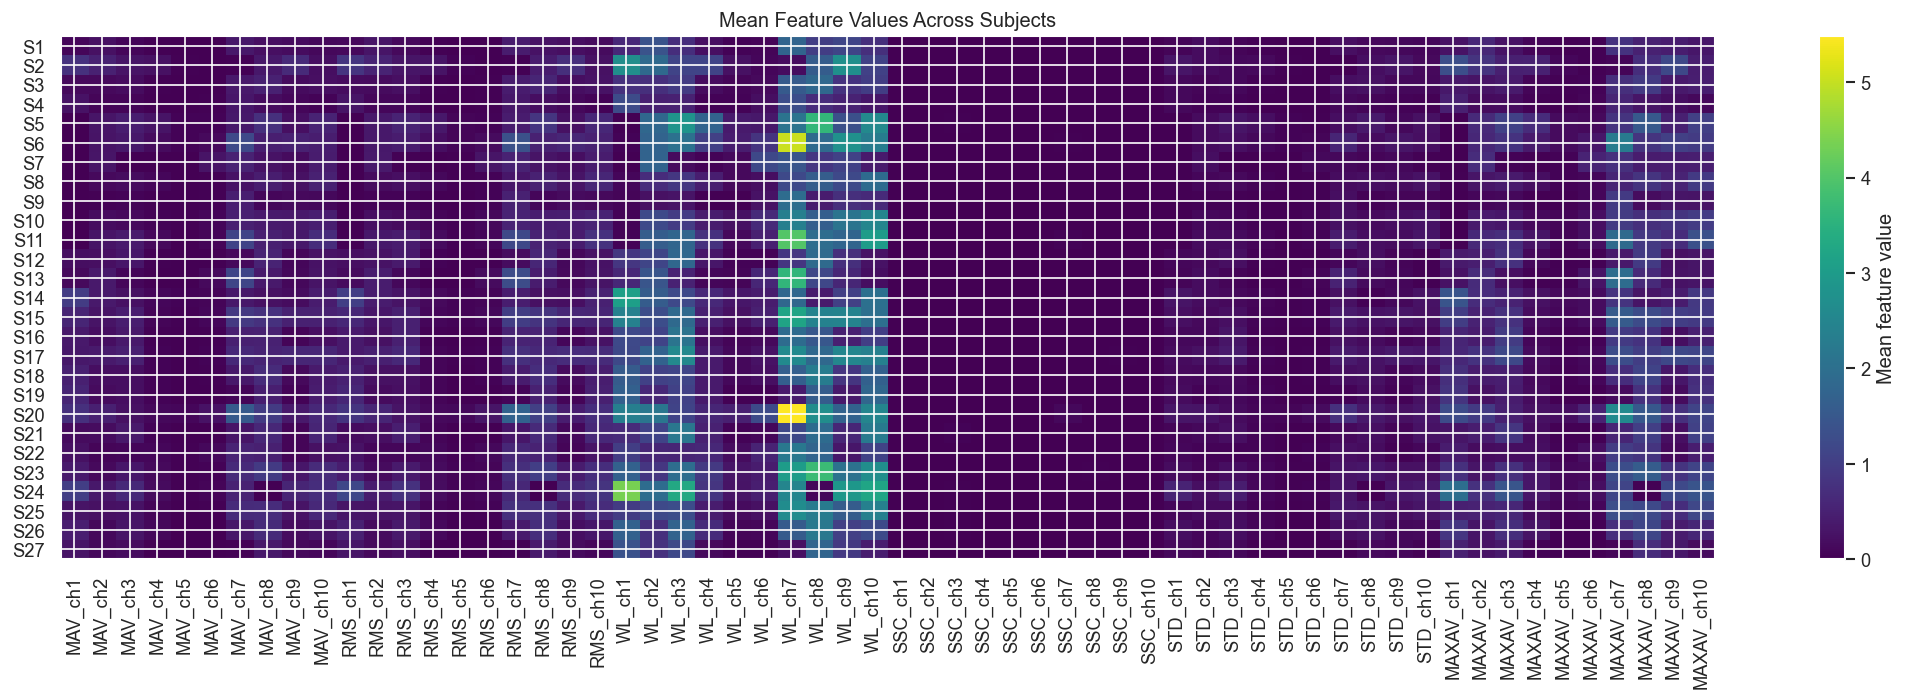

In [95]:
# Matrix of size 27 × 70
all_means = np.array([subject_feature_stats[s]["mean"] for s in sorted(subject_feature_stats.keys())])

plt.figure(figsize=(18, 6))
plt.imshow(all_means, aspect="auto", cmap="viridis")
plt.colorbar(label="Mean feature value")
plt.yticks(range(27), [f"S{s}" for s in sorted(subject_feature_stats.keys())])
plt.xticks(range(len(flat_feature_names)), flat_feature_names, rotation=90)

plt.title("Mean Feature Values Across Subjects")
plt.tight_layout()
plt.show()


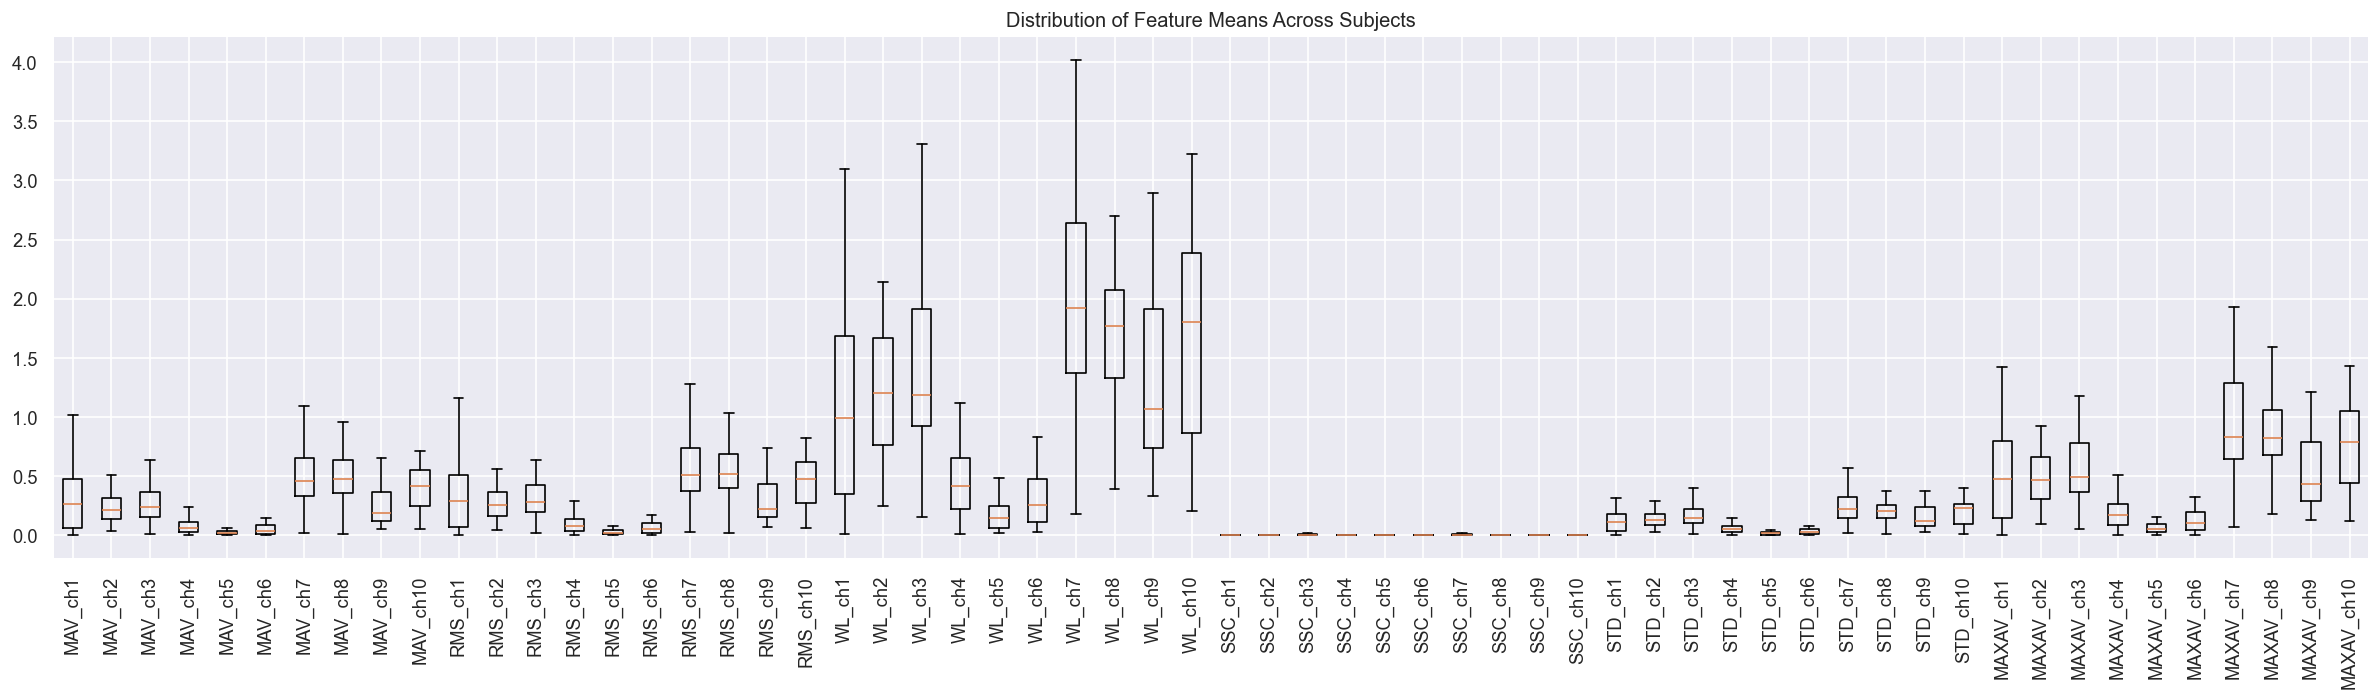

In [96]:
plt.figure(figsize=(20, 6))
plt.boxplot(all_means, showfliers=False)
plt.xticks(range(1, len(flat_feature_names)+1), flat_feature_names, rotation=90)
plt.title("Distribution of Feature Means Across Subjects")
plt.tight_layout()
plt.show()


Divide by their means to check which features differ the most across subjects

C:\Users\Simon\AppData\Local\Temp\ipykernel_37312\4210387073.py:1: RuntimeWarning: invalid value encountered in divide
  all_means_normalized = all_means / np.mean(all_means, axis=0, keepdims=True)


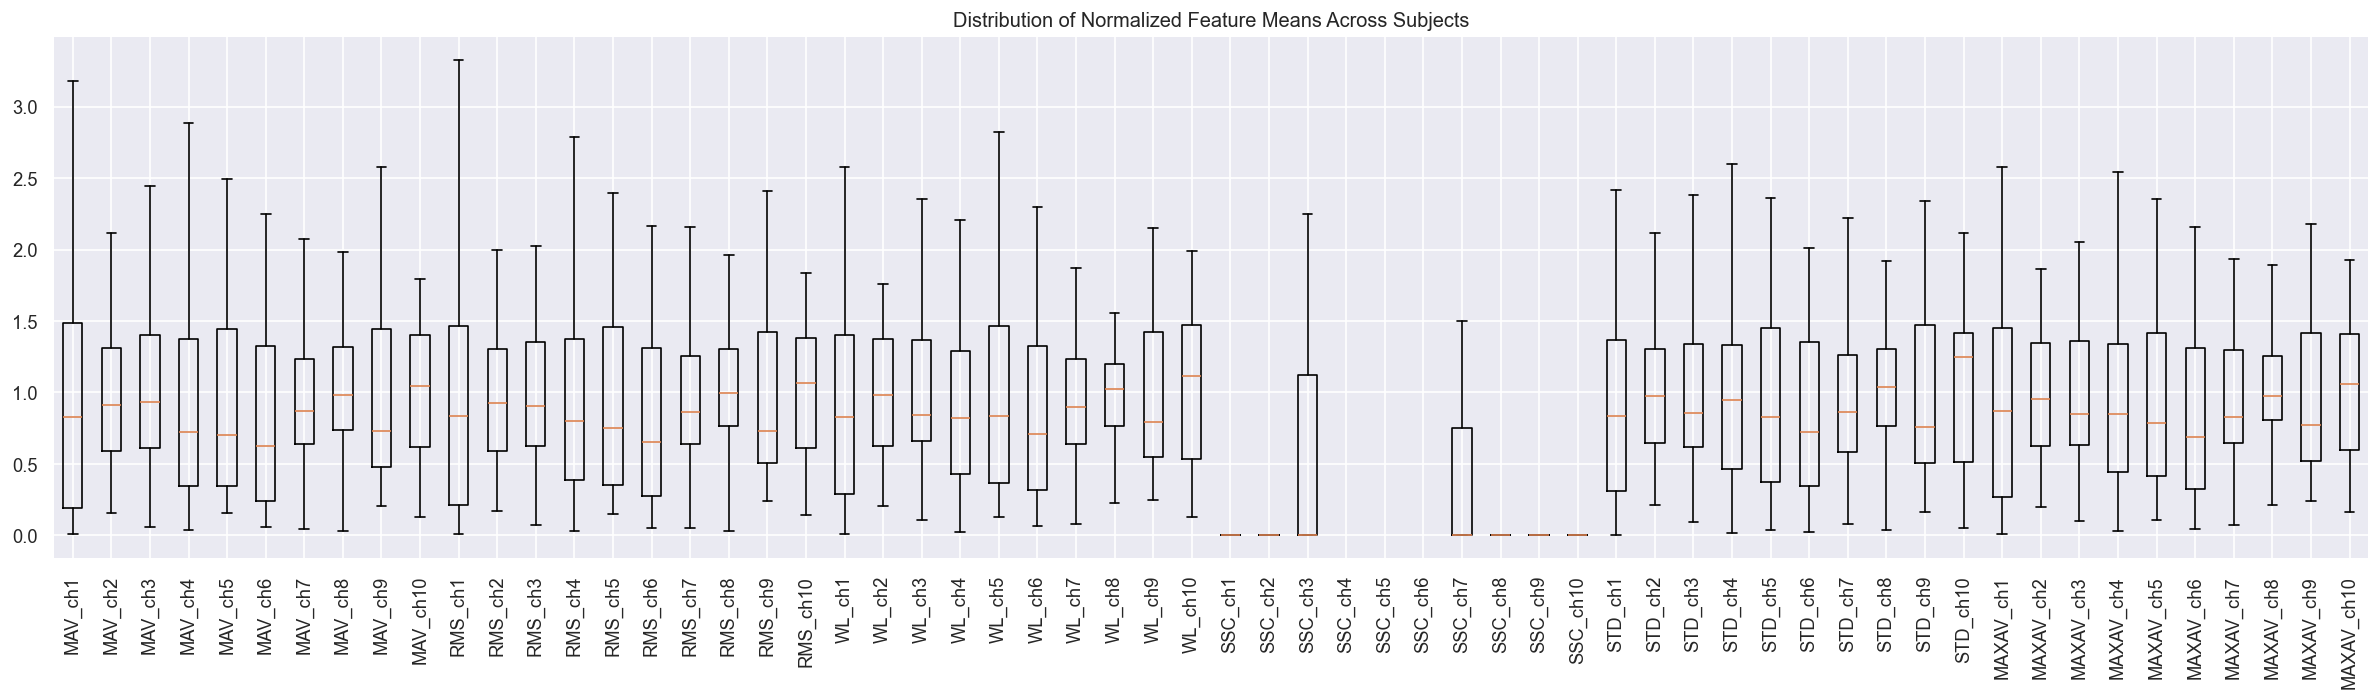

In [100]:
all_means_normalized = all_means / np.mean(all_means, axis=0, keepdims=True)
plt.figure(figsize=(20, 6))
plt.boxplot(all_means_normalized, showfliers=False)
plt.xticks(range(1, len(flat_feature_names)+1), flat_feature_names, rotation=90)
plt.title("Distribution of Normalized Feature Means Across Subjects")
plt.tight_layout()
plt.show()


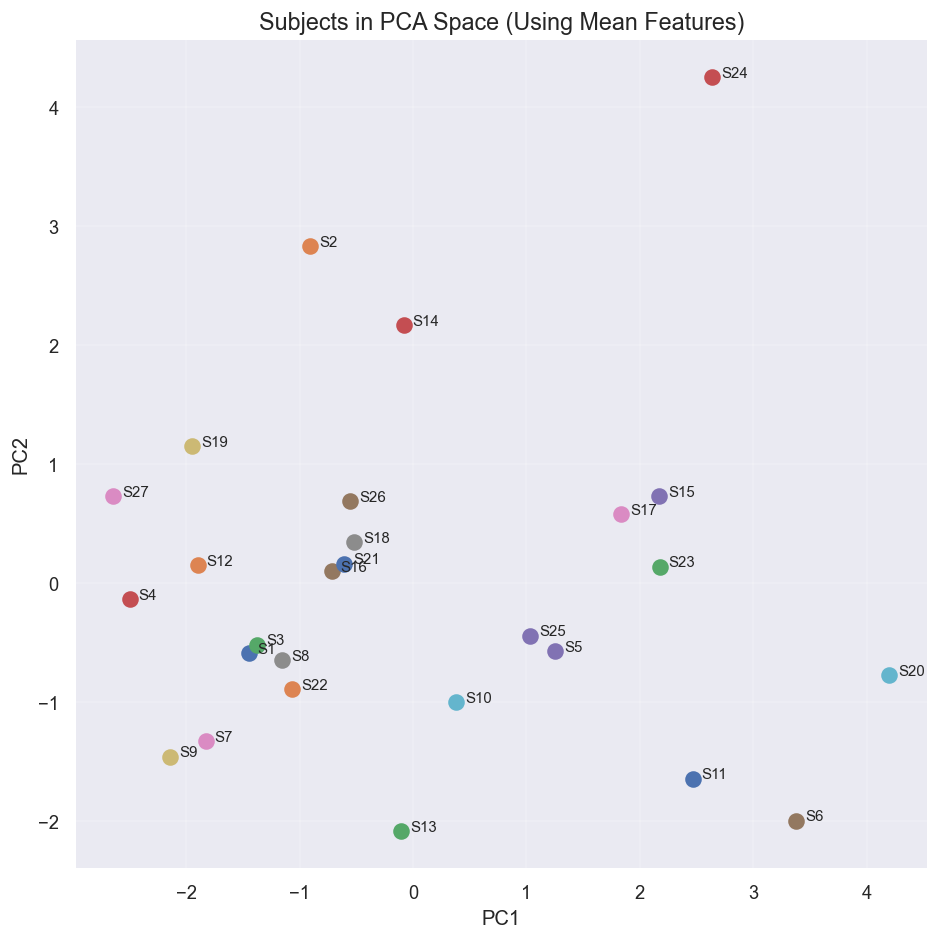

In [106]:
pca = PCA(n_components=2)
coords = pca.fit_transform(all_means)

plt.figure(figsize=(8, 8))
for i, sid in enumerate(sorted(subject_feature_stats.keys())):
    plt.scatter(coords[i,0], coords[i,1], s=80)
    plt.text(coords[i,0] + 0.08, coords[i,1], f"S{sid}", fontsize=9)

plt.title("Subjects in PCA Space (Using Mean Features)", fontsize=14)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()




## 3. Train a classification model (same model as part 1) on 26 subjects (aggregating the data) and test it on a subject outside the train set. Evaluate the performance. How does  it compare to training and testing on the same subject directly?  

Let's test on subject 2

In [108]:
test_subject_id = 2  # subject to leave out

X_train_list = []
y_train_list = []

X_test = None
y_test = None

for subj in subjects:
    sid = subj["subject_id"]

    # Extract features for this subject
    X_s, y_s, info_s = extract_features_for_subject(subj)

    if sid == test_subject_id:
        # This subject is the test set
        X_test = X_s
        y_test = y_s
    else:
        # All others go to training set
        X_train_list.append(X_s)
        y_train_list.append(y_s)

# Combine everything
X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (3120, 60)
Test set shape: (120, 60)


In [111]:
clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on left-out Subject {test_subject_id}: {acc:.3f}")


Accuracy on left-out Subject 2: 0.142


Random would be 10% probably

Possible reasons (ChatGPT): TODO

- muscle anatomy differs/different muscle activation for the same movement

- electrode positions differ (a few mm matters) --> I think they tried a lot to ensure that's consistent, look at paper again

- skin impedance (sweat, fat layer, etc)

Try to improve this?

- Feature normalization across subjects (e.g., per-channel z-score normalization)

- Domain adaptation (CORAL, TCA, DAN, DANN)

- Deep learning baselines (CNN features generalize better)

- Riemannian geometry + covariance features (works shockingly well in sEMG)

- Transfer learning with calibration samples

<!-- Try to improve this?

- Feature normalization across subjects

- Domain adaptation (CORAL, TCA, DAN, DANN)

- Deep learning baselnies (CNN features generalize better)

- Riemannian geometry + covariance features

- Transfer learning w/ calibration samples -->

## 4. Perform cross-validation by rotating the subject used for testing. Specifically, for each fold, select one subject as the test set and use the remaining 26 subjects to train the model. Repeat this process for all 27 subjects, ensuring each subject is used as the test set exactly once. Evaluate and compare the performance across all folds to understand how well the model generalizes to new subjects. 

In [112]:
loso_results = {}  # subject_id -> accuracy

for test_subject_id in sorted([s["subject_id"] for s in subjects]):
    X_train_list = []
    y_train_list = []
    X_test = None
    y_test = None

    # Build train/test split for this fold
    for subj in subjects:
        sid = subj["subject_id"]
        X_s, y_s, info_s = extract_features_for_subject(subj)

        if sid == test_subject_id:
            X_test = X_s
            y_test = y_s
        else:
            X_train_list.append(X_s)
            y_train_list.append(y_s)

    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)

    print(f"\n=== Fold: test subject {test_subject_id} ===")
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

    # Same model as Part 1
    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    loso_results[test_subject_id] = acc

    print(f"Accuracy on subject {test_subject_id}: {acc:.3f}")

# ---- Summary over all 27 folds ----
print("\n=== LOSO summary ===")
all_ids = sorted(loso_results.keys())
all_accs = np.array([loso_results[sid] for sid in all_ids])

for sid, acc in zip(all_ids, all_accs):
    print(f"Subject {sid:2d}: {acc:.3f}")

print(f"\nMean accuracy: {all_accs.mean():.3f}")
print(f"Std  accuracy: {all_accs.std():.3f}")


=== Fold: test subject 1 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 1: 0.317

=== Fold: test subject 2 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 2: 0.142

=== Fold: test subject 3 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 3: 0.458

=== Fold: test subject 4 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 4: 0.283

=== Fold: test subject 5 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 5: 0.392

=== Fold: test subject 6 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 6: 0.250

=== Fold: test subject 7 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 7: 0.367

=== Fold: test subject 8 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 8: 0.367

=== Fold: test subject 9 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 9: 0.133

=== Fold: test subject 10 ===
Train shape: (3120, 60) 

## 5. Repeat task 3 by varying the number of subjects in the training set (without performing cross-validation). For example, use subject 27 for testing, and train with subject 1, then  train with subjects 1 and 2, then 1, 2, and 3, and continue to increase number of  subjects used for training. Analyze how the size of the training set impacts the  classification performance on the test subject. Discuss the practical implications  of including  more or fewer subjects in the training data, focusing on trends in generalization and  accuracy. If you had to train a decoder, what would be your ideal training dataset and why?

Again take subject 2 for testing. Start once by using similar subjects in terms of the features (see visualization of features)

Subject 2 might not be ideal as it looks kind of isolated in the PCA plot but we can do a random order and a specific order for a different subject, too

Extract features for all subjects once to speed things up

In [114]:
all_features = {}  # subject_id -> (X, y)

for subj in subjects:
    sid = subj["subject_id"]
    X_s, y_s, info_s = extract_features_for_subject(subj)
    all_features[sid] = (X_s, y_s)

print("Precomputed all features.")


Precomputed all features.


First in order (w/o looking at distance in feature space)

In [115]:
test_subject_id = 2
training_order = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                  16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]

accuracies_progressive = []
num_train_subjects = []

X_test, y_test = all_features[test_subject_id]

for k in range(1, len(training_order) + 1):
    train_subjects = training_order[:k]

    # Build training set
    X_train = np.vstack([all_features[sid][0] for sid in train_subjects])
    y_train = np.hstack([all_features[sid][1] for sid in train_subjects])

    # Train classifier
    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies_progressive.append(acc)
    num_train_subjects.append(k)

    print(f"Training on {k:2d} subjects → acc = {acc:.3f}")

Training on  1 subjects → acc = 0.117
Training on  2 subjects → acc = 0.067
Training on  3 subjects → acc = 0.100
Training on  4 subjects → acc = 0.108
Training on  5 subjects → acc = 0.125
Training on  6 subjects → acc = 0.183
Training on  7 subjects → acc = 0.158
Training on  8 subjects → acc = 0.100
Training on  9 subjects → acc = 0.058
Training on 10 subjects → acc = 0.017
Training on 11 subjects → acc = 0.050
Training on 12 subjects → acc = 0.067
Training on 13 subjects → acc = 0.117
Training on 14 subjects → acc = 0.117
Training on 15 subjects → acc = 0.067
Training on 16 subjects → acc = 0.067
Training on 17 subjects → acc = 0.075
Training on 18 subjects → acc = 0.117
Training on 19 subjects → acc = 0.075
Training on 20 subjects → acc = 0.108
Training on 21 subjects → acc = 0.142
Training on 22 subjects → acc = 0.142
Training on 23 subjects → acc = 0.158
Training on 24 subjects → acc = 0.117
Training on 25 subjects → acc = 0.158
Training on 26 subjects → acc = 0.142


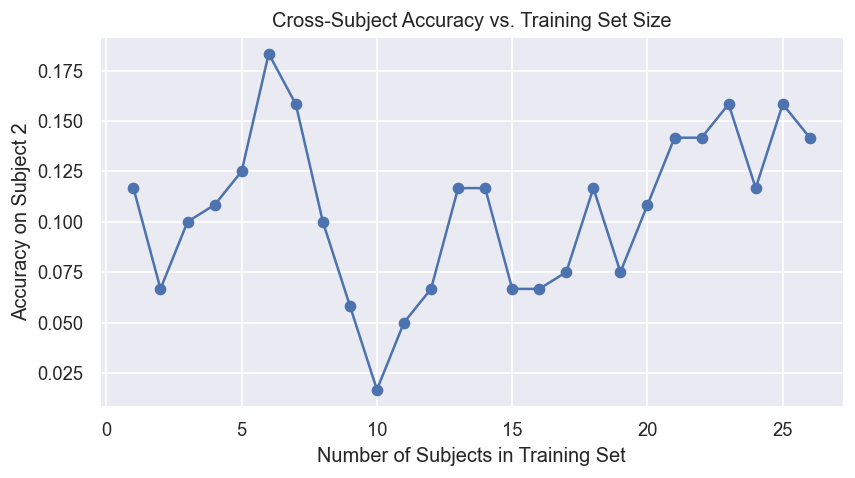

In [116]:
plt.figure(figsize=(8, 4))
plt.plot(num_train_subjects, accuracies_progressive, marker="o")
plt.xlabel("Number of Subjects in Training Set")
plt.ylabel("Accuracy on Subject 2")
plt.title("Cross-Subject Accuracy vs. Training Set Size")
plt.grid(True)
plt.show()


Smarter order:

Compute subject centroids in feature space

In [117]:
subject_means = {sid: np.mean(all_features[sid][0], axis=0)
                 for sid in all_features}

PCA reduce to 5D

In [118]:
pca = PCA(n_components=5)
mat = np.vstack([subject_means[s] for s in sorted(subject_means.keys())])
coords = pca.fit_transform(mat)

# Map subject_id -> PCA coordinates
pca_coords = {sid: coords[i] for i, sid in enumerate(sorted(subject_means.keys()))}

Compute distance to test subject

In [119]:
test_coord = pca_coords[test_subject_id]

# compute Euclidean distance to subject 2
distances = {
    sid: np.linalg.norm(pca_coords[sid] - test_coord)
    for sid in pca_coords if sid != test_subject_id
}

# sort subjects by increasing distance
sorted_by_similarity = sorted(distances, key=lambda sid: distances[sid])

print("Subjects sorted by similarity to subject 2:")
print(sorted_by_similarity)

Subjects sorted by similarity to subject 2:
[27, 26, 14, 12, 19, 18, 1, 16, 3, 17, 15, 8, 4, 21, 25, 10, 7, 22, 23, 24, 9, 5, 13, 11, 6, 20]


Repeat progressive training using similarity ordering

In [120]:
accuracies_similarity = []
num_train_subjects = []
X_test, y_test = all_features[test_subject_id]

for k in range(1, len(sorted_by_similarity) + 1):
    train_subs = sorted_by_similarity[:k]

    X_train = np.vstack([all_features[s][0] for s in train_subs])
    y_train = np.hstack([all_features[s][1] for s in train_subs])

    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies_similarity.append(acc)
    num_train_subjects.append(k)

    print(f"Training on {k:2d} similar subjects → acc = {acc:.3f}")


Training on  1 similar subjects → acc = 0.150
Training on  2 similar subjects → acc = 0.158
Training on  3 similar subjects → acc = 0.175
Training on  4 similar subjects → acc = 0.192
Training on  5 similar subjects → acc = 0.108
Training on  6 similar subjects → acc = 0.183
Training on  7 similar subjects → acc = 0.083
Training on  8 similar subjects → acc = 0.125
Training on  9 similar subjects → acc = 0.125
Training on 10 similar subjects → acc = 0.200
Training on 11 similar subjects → acc = 0.150
Training on 12 similar subjects → acc = 0.117
Training on 13 similar subjects → acc = 0.100
Training on 14 similar subjects → acc = 0.150
Training on 15 similar subjects → acc = 0.158
Training on 16 similar subjects → acc = 0.158
Training on 17 similar subjects → acc = 0.133
Training on 18 similar subjects → acc = 0.092
Training on 19 similar subjects → acc = 0.175
Training on 20 similar subjects → acc = 0.125
Training on 21 similar subjects → acc = 0.167
Training on 22 similar subjects → 

Plot both curves

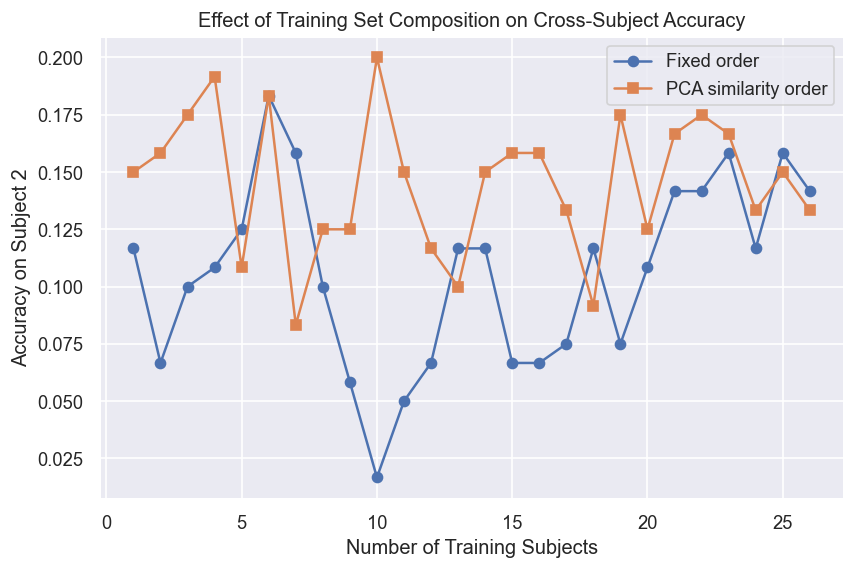

In [121]:
plt.figure(figsize=(8,5))
plt.plot(num_train_subjects, accuracies_progressive, marker='o', label="Fixed order")
plt.plot(num_train_subjects, accuracies_similarity, marker='s', label="PCA similarity order")
plt.xlabel("Number of Training Subjects")
plt.ylabel("Accuracy on Subject 2")
plt.title("Effect of Training Set Composition on Cross-Subject Accuracy")
plt.grid(True)
plt.legend()
plt.show()


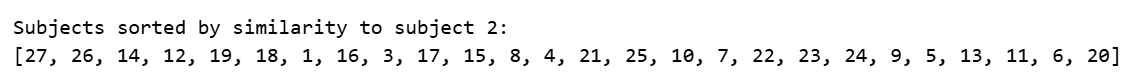

<span style="color:red">TODO</span>

Analyze how the size of the training set impacts the classification performance on the test subject. 

Discuss the practical implications  of including  more or fewer subjects in the training data, focusing on trends in 
generalization and  accuracy. 

If you had to train a decoder, what would be your ideal training dataset and why? 

### With normalization

In [124]:
# Fit scaler on training features only
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm  = scaler.transform(X_test)

print("X_train_norm shape:", X_train_norm.shape)
print("X_test_norm shape:", X_test_norm.shape)

X_train_norm shape: (3120, 60)
X_test_norm shape: (120, 60)


In [125]:
clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

clf.fit(X_train_norm, y_train)
y_pred = clf.predict(X_test_norm)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on left-out Subject {test_subject_id}: {acc:.3f}")

Accuracy on left-out Subject 2: 0.133


In [ ]:
loso_results = {}  # subject_id -> accuracy

for test_subject_id in sorted([s["subject_id"] for s in subjects]):
    X_train_list = []
    y_train_list = []
    X_test = None
    y_test = None

    # Build train/test split for this fold
    for subj in subjects:
        sid = subj["subject_id"]
        X_s, y_s, info_s = extract_features_for_subject(subj)

        if sid == test_subject_id:
            X_test = X_s
            y_test = y_s
        else:
            X_train_list.append(X_s)
            y_train_list.append(y_s)

    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)

    print(f"\n=== Fold: test subject {test_subject_id} ===")
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

    # -------- Normalization (fit only on training!) --------
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm  = scaler.transform(X_test)

    # -------- Gradient Boosting Model --------
    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    clf.fit(X_train_norm, y_train)
    y_pred = clf.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)
    loso_results[test_subject_id] = acc

    print(f"Accuracy on subject {test_subject_id}: {acc:.3f}")

# ---- Summary over all folds ----
print("\n=== LOSO summary ===")
all_ids = sorted(loso_results.keys())
all_accs = np.array([loso_results[sid] for sid in all_ids])

for sid, acc in zip(all_ids, all_accs):
    print(f"Subject {sid:2d}: {acc:.3f}")

print(f"\nMean accuracy: {all_accs.mean():.3f}")
print(f"Std  accuracy: {all_accs.std():.3f}")



=== Fold: test subject 1 ===
Train shape: (3120, 60) Test shape: (120, 60)
Accuracy on subject 1: 0.325

=== Fold: test subject 2 ===
Train shape: (3120, 60) Test shape: (120, 60)


Normalized progressive training

In [ ]:
all_features = {}  # subject_id -> (X, y)

# Precompute features for all subjects
for subj in subjects:
    sid = subj["subject_id"]
    X_s, y_s, info_s = extract_features_for_subject(subj)
    all_features[sid] = (X_s, y_s)

print("Precomputed all features.")

# Fix test subject
test_subject_id = 2

training_order = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                  16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]

accuracies_progressive = []
num_train_subjects = []

# Test set stays fixed (normalize it EACH iteration with scaler fitted on training set)
X_test, y_test = all_features[test_subject_id]

for k in range(1, len(training_order) + 1):
    train_subjects = training_order[:k]

    # Build unnormalized training set
    X_train = np.vstack([all_features[sid][0] for sid in train_subjects])
    y_train = np.hstack([all_features[sid][1] for sid in train_subjects])

    # -------- Normalization per step (fit on training only!) --------
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm  = scaler.transform(X_test)

    # -------- Train classifier --------
    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    clf.fit(X_train_norm, y_train)
    y_pred = clf.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)

    accuracies_progressive.append(acc)
    num_train_subjects.append(k)

    print(f"Training on {k:2d} subjects → acc = {acc:.3f}")

In [ ]:
# --- Plot for the fixed training order (already using normalized accuracies_progressive) ---
plt.figure(figsize=(8, 4))
plt.plot(num_train_subjects, accuracies_progressive, marker="o")
plt.xlabel("Number of Subjects in Training Set")
plt.ylabel("Accuracy on Subject 2")
plt.title("Cross-Subject Accuracy vs. Training Set Size")
plt.grid(True)
plt.show()


In [ ]:
# --- PCA-based similarity between subjects (on mean feature vectors) ---
subject_means = {sid: np.mean(all_features[sid][0], axis=0)
                 for sid in all_features}

pca = PCA(n_components=5)
mat = np.vstack([subject_means[s] for s in sorted(subject_means.keys())])
coords = pca.fit_transform(mat)

# Map subject_id -> PCA coordinates
pca_coords = {sid: coords[i] for i, sid in enumerate(sorted(subject_means.keys()))}

test_coord = pca_coords[test_subject_id]

# compute Euclidean distance to subject 2
distances = {
    sid: np.linalg.norm(pca_coords[sid] - test_coord)
    for sid in pca_coords if sid != test_subject_id
}

# sort subjects by increasing distance
sorted_by_similarity = sorted(distances, key=lambda sid: distances[sid])

print("Subjects sorted by similarity to subject 2:")
print(sorted_by_similarity)


In [ ]:
accuracies_similarity = []
num_train_subjects_sim = []  # to avoid confusion with the other curve
X_test, y_test = all_features[test_subject_id]

for k in range(1, len(sorted_by_similarity) + 1):
    train_subs = sorted_by_similarity[:k]

    # Build unnormalized training set
    X_train = np.vstack([all_features[s][0] for s in train_subs])
    y_train = np.hstack([all_features[s][1] for s in train_subs])

    # ---- Normalization (fit on training subjects only) ----
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm  = scaler.transform(X_test)

    # ---- Classifier ----
    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    clf.fit(X_train_norm, y_train)
    y_pred = clf.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)

    accuracies_similarity.append(acc)
    num_train_subjects_sim.append(k)

    print(f"Training on {k:2d} similar subjects → acc = {acc:.3f}")

In [ ]:
# --- Comparison plot: fixed order vs PCA-similarity order ---
plt.figure(figsize=(8, 5))
plt.plot(num_train_subjects, accuracies_progressive, marker='o', label="Fixed order")
plt.plot(num_train_subjects_sim, accuracies_similarity, marker='s', label="PCA similarity order")
plt.xlabel("Number of Training Subjects")
plt.ylabel("Accuracy on Subject 2")
plt.title("Effect of Training Set Composition on Cross-Subject Accuracy")
plt.grid(True)
plt.legend()
plt.show()
